# **BÀI TẬP 2: THỐNG KÊ MÁY TÍNH VÀ ỨNG DỤNG**

---
## **Thông tin sinh viên**

##### **Họ tên:** Lý Liên Hoa
##### **MSSV:** 22127117

---

##### **Thư viện**

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import norm

---

## **Câu 1**

Cho tập $S = \{1, 2, … , 50\}$.  
&nbsp;&nbsp;&nbsp;&nbsp;$a$. Thiết kế thuật toán sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$.  
&nbsp;&nbsp;&nbsp;&nbsp;$b$. Thiết kết thuật toán sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$ với điều kiện tập con đó có chứa ít nhất 3 phần tử từ tập $C = \{1, 2, 3, 4, 5\}$. Từ đó ước lượng xác suất tập con sinh được chỉ chứa các phần tử trong $C$.

---

### **a. Thiết kế thuật toán sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$.**

#### **Lý thuyết**

Số tập con có $4$ phần tử được ngẫu nhiên được sinh ra từ tập $S = \{1, 2, … , 50\}$.  
$$
C_{50}^{4} = 230.300 \quad \text{(tập con)}
$$

#### **Code**

In [2]:
# Tạo tập S
S = list(range(1, 51))

print(f"S = {S}")

S = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


- Sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$

In [3]:
def gen_subsets(S, n=4):
    return random.sample(S, n)

In [4]:
subsets = gen_subsets(S)

subsets

[28, 40, 10, 34]

<br>

### **b. Thiết kết thuật toán sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$ với điều kiện tập con đó có chứa ít nhất 3 phần tử từ tập $C = \{1, 2, 3, 4, 5\}$. Từ đó ước lượng xác suất tập con sinh được chỉ chứa các phần tử trong $C$.**

#### **Lý thuyết**

Số tập con ngẫu nhiên gồm $4$ phần tử chỉ chứa các phần tử trong $C = \{1, 2, 3, 4, 5\}$:
$$
C^{4}_{5} = 5 \quad \text{(tập con)}
$$

Số tập con ngẫu nhiên gồm $4$ phần tử sinh từ tập  $S = \{1, 2, … , 50\}$ với điều kiện tập con đó có chứa ít nhất 3 phần tử từ tập $C$.  
$$
C^{3}_{5}\times C^{1}_{45} + C^{4}_{5}\times C^{0}_{45} = 455 \quad \text{(tập con)}
$$

Xác suất tập con sinh được chỉ chứa các phần tử trong $C$:
$$
\frac{C^{4}_{5}}{C^{3}_{5}\times C^{1}_{45} + C^{4}_{5}\times C^{0}_{45}} = \frac{1}{91} \approx 0.01098901099
$$

#### **Code**

- Sinh tập con ngẫu nhiên gồm 4 phần tử từ $S$ với điều kiện tập con đó có chứa ít nhất 3 phần tử từ tập $C$

In [5]:
def gen_subsets_at_least_3_from_C(S, C, n=4):
    while True:
        subset = random.sample(S, n)
        common_elements_count = len(set(subset) & set(C))
        
        if common_elements_count >= 3:
            return subset

In [6]:
C = [1, 2, 3, 4, 5]

print(gen_subsets_at_least_3_from_C(S, C))

[2, 1, 6, 3]


- Mô phỏng

In [7]:
def simulate_prob_only_elements_from_C_subsets(S, C, n=4, simulations=100000):
    if n > len(C):
        return None
    
    all_elements_C_subsets_count = 0
    
    for _ in range(simulations):
        subset = gen_subsets_at_least_3_from_C(S, C, n)
        common_elements_count = len(set(subset) & set(C))
        
        if common_elements_count == n:
            all_elements_C_subsets_count += 1
            
    return all_elements_C_subsets_count / simulations

In [8]:
simulate_prob_only_elements_from_C_subsets(S, C)

0.01124

---

## **Câu 2**

Thiết kế thuật toán sinh số ngẫu nhiên $X$ có hàm mật độ xác suất được cho và từ đó ước lượng kì vọng của $X$.


&nbsp;&nbsp;&nbsp;&nbsp;$a. \quad f(x) = \frac{1}{2}e^{-|x|}$  

&nbsp;&nbsp;&nbsp;&nbsp;$b. \quad f(x) = \frac{5}{2}e^{-\frac{5}{2}(x - 2)}$, $x \ge 2$

&nbsp;&nbsp;&nbsp;&nbsp;$d. \quad f(x) = $
$
\begin{cases}
x \;,  \quad 0 \le x \le 1 \\
1 \;, \quad 1 < x \le \frac{3}{2}
\end{cases}
$

&nbsp;&nbsp;&nbsp;&nbsp;$c. \quad f(x) = \frac{1}{\pi(1 + x^2)}$

----

### **$a. \quad f(x) = \frac{1}{2}e^{-|x|}$**

#### **Lý thuyết**

$X$ là biến ngẫu liên tục trên $(-\infty, +\infty)$

Hàm phân phối tích lũy được biểu diễn dưới dạng:
$$
F(x) = P(X \le x) = \int_{-\infty}^{x}f(t)\,dt
$$

$\Rightarrow X$ có phân phối $F$: $\quad X \sim F$

- Với $x \ge 0$, ta có:
$$
F(x) = \int_{-\infty}^{x} f(t)\,dt
$$

$$
\Rightarrow
F(x) = \int_{-\infty}^{0}f(t)\,dt + \int_{0}^{x} f(t)\,dt = \int_{-\infty}^{0} \frac{1}{2}e^{t}\,dt + \int_{0}^{x} \frac{1}{2}e^{-t}\,dt  \\
$$

$$
= \frac{1}{2}e^{t}\Big|_{-\infty}^{0} -\frac{1}{2}e^{-t} \Big|_{0}^{x} =\frac{1}{2} + \frac{1}{2} -\frac{1}{2}e^{-x}
$$

$
\quad\quad
\Rightarrow F(x) = 1 - \frac{1}{2}e^{-x}
$

$\quad\quad$ Vì:

$$
\begin{cases}
x < 0 \\ 
x \to -\infty
\end{cases}
\Rightarrow e^x \to 0
$$


- Với $x < 0$
$$
F(x) = \int_{-\infty}^{x}f(t)dt = \int_{-\infty}^{x} \frac{1}{2}e^{t}dt = \frac{1}{2}e^{t}\Big|_{-\infty}^{x}
$$

$
\quad\quad
\Rightarrow F_{X}(x) = \frac{1}{2} e^{x}
$

$\Rightarrow$ Hàm phân phối tích lũy có dạng:
$$
F(x) = 
\begin{cases}
1 - \frac{1}{2}e^{-x}, & x \ge 0 \\
 \frac{1}{2}e^{x} & x < 0
\end{cases}
$$

Nếu ta sinh ngẫu nhiên một số  $u \sim U(0, 1)$, bằng **phương pháp biến đổi ngược**, ta có thể sinh $X$ từ hàm phân phối $F(x)$, bằng cách giải phương trình $F(x) = u$:

- Với $x \ge 0$

$$
F(x) = 1 - \frac{1}{2}e^{-x} = u
$$

$$
\begin{aligned}

&\Rightarrow
2 - e^{-x} = 2u \\

&\Rightarrow
e^{-x} = 2 - 2u \\

&\Rightarrow
-x = ln(2 - 2u) \\

&\Rightarrow
x = -ln(2 - 2u) \\

\end{aligned}
$$

$\quad\quad$ Khi $x \ge 0$ thì $e^{-x} = \frac{1}{e^{x}} \le 1 \Rightarrow -\frac{1}{2}e^{-x} \ge -\frac{1}{2} \Rightarrow  1 - \frac{1}{2}e^{-x} \ge \frac{1}{2}$

$\quad\quad \Rightarrow u \ge \frac{1}{2}$

- Với $x < 0$

$$
F(x) = \frac{1}{2} e^{x} = u
$$

$$
\begin{aligned}
&\Rightarrow e^x = 2u \\

&\Rightarrow x = ln(2u)

\end{aligned}
$$

$\quad\quad$ Khi $x < 0 \Rightarrow \frac{1}{2} e^{x} < \frac{1}{2}$

$\quad\quad \Rightarrow u < \frac{1}{2}$

$\Rightarrow$ Như vậy, với $u \sim U(0, 1)$ thì $X$ được sinh ra bằng cách:
$$
X = 
\begin{cases}
-ln(2 - 2u), & u \ge \frac{1}{2} \\
ln(2u), & u < \frac{1}{2}
\end{cases}
$$

Kì vọng của biến ngẫu nhiên $X$ được tính bởi:
$$
E[X] = \int_{-\infty}^{+\infty}xf(x)\,dx
$$

$$
\Rightarrow E[X] = \int_{-\infty}^{0} x \frac{1}{2} e^x \,dx + \int_{0}^{+\infty} x \frac{1}{2} e^{-x} \,dx
$$

- Xét $I_1 = \int_{-\infty}^{0} x \frac{1}{2} e^x \,dx = \frac{1}{2} \cdot \int_{-\infty}^{0} x e^x \,dx$, ta có:

$\quad\quad$ Công thức tích phân từng phần:

$$
\int u \, dv = uv - \int v \, du
$$

$\quad\quad$ Chọn:  
$\quad\quad\quad$ - $u = x \Rightarrow du = dx$  
$\quad\quad\quad$ - $dv = e^x dx \Rightarrow v = e^x$  

$$
I = \frac{1}{2} \cdot \int_{-\infty}^{0} x e^x \,dx
$$

$\quad\quad$ Sử dụng tích phân từng phần:

$$
I_1 = \frac{1}{2} \cdot \left(x e^x - \int_{-\infty}^{0} e^x\,dx \right) = \frac{1}{2} x e^x - \frac{1}{2}
$$


- Tương tự, xét $I_2 = \frac{1}{2} \cdot \int_{0}^{\infty}xe^{-x}\,dx$, ta có:
$$
I_2 = \frac{1}{2} \cdot \int_{0}^{+\infty}xe^{-x}\,dx = -\frac{1}{2}xe^{-x} + \frac{1}{2}
$$

$\Rightarrow E[X] = I_1 + I_2 = 0$

#### **Code**

- Sinh số ngẫu nhiên $X$

In [9]:
def gen_X_2a():
    u = random.uniform(0, 1)
    
    if u >= 0.5:
        return - np.log(2 - 2 * u)
    else:
        return np.log(2 * u)

In [10]:
print(f"X = {gen_X_2a()}")

X = -0.6837995628661868


- Mô phỏng

In [11]:
def simulate_2a(simulations=100000):
    samples = []
    
    for _ in range(simulations):
        samples.append(gen_X_2a())
        
    return samples, np.mean(samples)

In [12]:
samples, estimated = simulate_2a()

print (f"-> Ước lượng kì vọng: {estimated}")

-> Ước lượng kì vọng: 0.00583508937942959


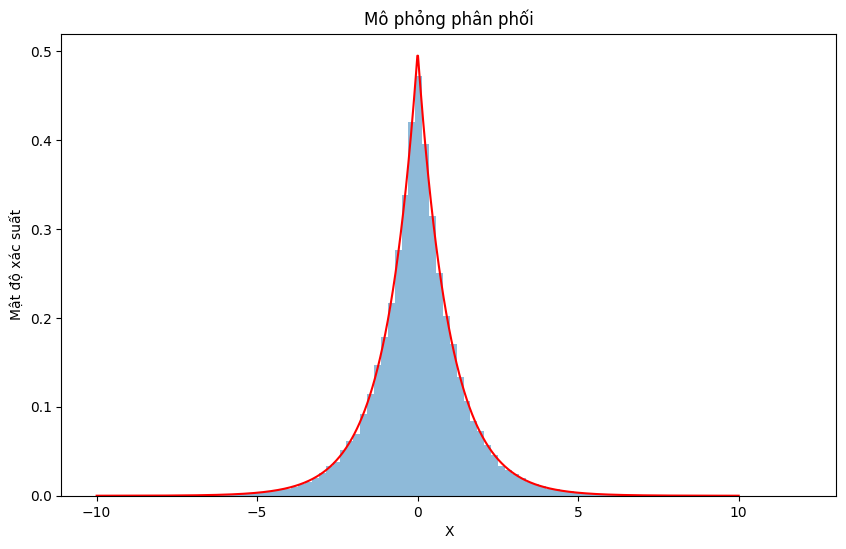

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(samples, bins=100, density=True, alpha=0.5)

x_values = np.linspace(-10, 10, 1000)  
pdf_values = 0.5 * np.exp(-np.abs(x_values))  

plt.title("Mô phỏng phân phối")
plt.xlabel("X")
plt.ylabel("Mật độ xác suất")

plt.plot(x_values, pdf_values, color='red', label='Hàm mật độ xác suất')

plt.show()

<br>

### **$b. \quad f(x) = \frac{5}{2}e^{-\frac{5}{2}(x - 2)}$, $x \ge 2$**

#### **Lý thuyết**

Gọi $X$ là biến ngẫu nhiên liên tục trên $[2, +\infty)$

Hàm phân phối của $X$ được biểu diễn dưới dạng:
$$
F(x) = P(X \le x) = \int_{2}^{x} f(t) \,dt = \int_{2}^{x} \frac{5}{2} e^{-\frac{5}{2}(t - 2)} \,dt
$$

$\Rightarrow X$ có phân phối $F$: $\quad X \sim F$

Đặt $Y = X - 2$ hay $X = Y + 2$. Hàm mật độ $Y$ có dạng phân phối mũ với tham số $\lambda = \frac{5}{2}$:
$$
f_{Y}(y) = \frac{5}{2} e^{-\frac{5}{2}y}, \quad y \ge 0
$$

Và:


$$
F_X(x) = P(X \le x) = P(Y + 2 \le x) = P(Y \le x - 2) = F_Y(x - 2)
$$

$$
\Rightarrow F_X(x) = F_Y(x - 2) = P(Y \le x - 2)
$$

$$
\Rightarrow
F_X(x) = \int_{0}^{x - 2} f_Y(y)\,dy
$$

$$
\Rightarrow
F_X(x) = \int_{0}^{x - 2} \, \frac{5}{2} e^{-\frac{5}{2}y} \,dy
$$

$$
\begin{aligned}

&\Rightarrow
F_X(x) = \frac{5}{2} \cdot \left(-\frac{2}{5} e^{-\frac{5}{2}y} \right) \Big|_{0}^{x - 2} \\ \\

&\Rightarrow
F_X(x) = \frac{5}{2} \cdot \left( -\frac{2}{5}e^{-\frac{5}{2}(x - 2)} + \frac{2}{5}\right) \\ \\

&\Rightarrow
F_X(x) = 1 - e^{-\frac{5}{2}(x - 2)}

\end{aligned}
$$

$\Rightarrow$ Hàm phân phối tích lũy có dạng:
$$
F(x) = 1 - e^{-\frac{5}{2}(x - 2)}, \quad x \ge 2
$$

Nếu ta sinh ngẫu nhiên một số  $u \sim U(0, 1)$, bằng **phương pháp biến đổi ngược**, ta có thể sinh $X$ từ hàm phân phối $F(x)$, bằng cách giải phương trình $F(x) = u$. Ta có:

$$
\begin{aligned}

F(x) = 1 - e^{-\frac{5}{2}(x - 2)} = u \quad

&\Rightarrow
e^{-\frac{5}{2}(x - 2)} = 1 - u \\

&\Rightarrow
-\frac{5}{2}(x - 2) = ln(1 - u) \\ \\

&\Rightarrow
x = 2 - \frac{2}{5} \cdot ln(1 - u)

\end{aligned}
$$

Như vậy, với $u \sim U(0, 1)$ thì $X$ được sinh ra bằng cách:
$$
X = 2 - \frac{2}{5} \cdot ln(1 - u)
$$

Kì vọng ngẫu nhiên của biến ngẫu nhiên $X$ được tính bởi:
$$
E[X] = E[Y + 2] = E[Y] + 2 = \frac{1}{\lambda} + 2 = \frac{2}{5} + 2 = \frac{12}{5} = 2.4
$$

#### **Code**

- Sinh số ngẫu nhiên $X$

In [14]:
def gen_X_2b():
    u = random.uniform(0, 1)
    
    return 2 - 0.4 * np.log(1 - u)

In [15]:
gen_X_2b()

2.2669586550825493

- Mô phỏng

In [16]:
def simulate_2b(simulations=100000):
    samples = []
    
    for _ in range(simulations):
        samples.append(gen_X_2b())
        
    return samples, np.mean(samples)

In [17]:
samples, estimated = simulate_2b()

print (f"-> Ước lượng kì vọng: {estimated}")

-> Ước lượng kì vọng: 2.399016398842787


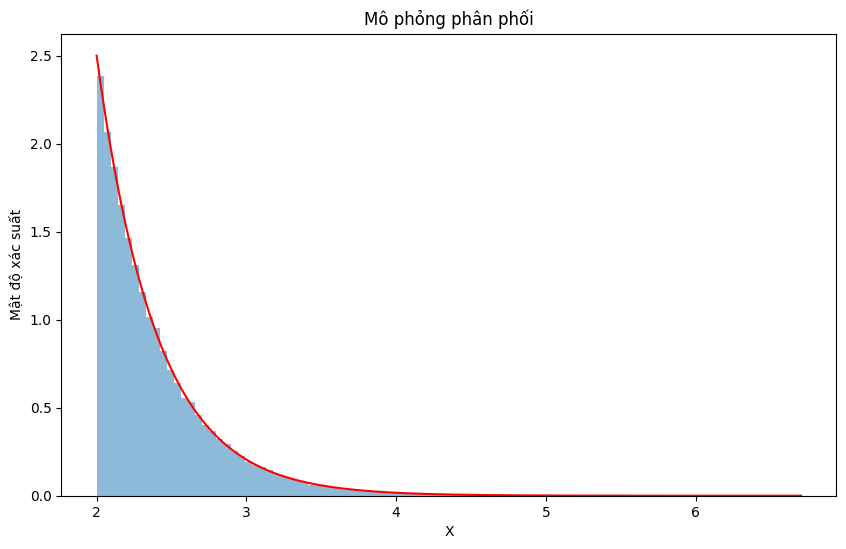

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(samples, bins=100, density=True, alpha=0.5)

x_values = np.linspace(2, np.max(samples), 1000)  
pdf_values = 2.5 * np.exp(-2.5 * (x_values - 2))  

plt.title("Mô phỏng phân phối")
plt.xlabel("X")
plt.ylabel("Mật độ xác suất")

plt.plot(x_values, pdf_values, color='red', label='Hàm mật độ xác suất')

plt.show()

<br>

### **$c. \quad f(x) = \begin{cases} x \;,  \quad 0 \le x \le 1 \\ 1 \;, \quad 1 < x \le \frac{3}{2} \end{cases}$**

#### **Lý thuyết**

$X$ là biến ngẫu nhiên liên tục trên $[0, \frac{3}{2}]$

Hàm phân phối tích lũy được biểu diễn dưới dạng:

$$
F(x) = P(X \le x) = \int_{-\infty}^{x} f(t) \, dt
$$

$\Rightarrow X$ có phân phối $F$: $\quad X \sim F$

- Với $x < 0$:

$$
F(x) = \int_{-\infty}^{x} f(t) \, dt = 0
$$

- Với $0 \le x \le 1$:

$$
F(x) =  \int_{-\infty}^{0} f(t) \, dt + \int_{0}^{x} f(t) \, dt = \int_{0}^{x} t \, dt = \left( \frac{t^2}{2} \right) \Big|_{0}^{x} = \frac{x^2}{2}
$$

- Với $1 < x \le \frac{3}{2}$:

$$
\begin{aligned}

F(x) &= \int_{0}^{1} f(t) \, dt + \int_{1}^{x} f(t) \, dt \\
     &= \int_{0}^{1} t \, dt + \int_{1}^{x} 1 \, dt \\
     &= \left( \frac{t^2}{2} \right) \Big|_{0}^{1} + (t) \; \Big|_{1}^{x} \\
     &= \frac{1}{2} + x - 1 \\
     &= x - \frac{1}{2}


\end{aligned}
$$

- Với $x \le \frac{3}{2}$:

$$
F(x) = \int_{-\infty}^{0} f(t) \, dt + \int_{0}^{1} f(t) \, dt + \int_{1}^{\frac{3}{2}} f(t) \, dt + \int_{\frac{3}{2}}^{+\infty} f(t) \, dt
$$

$$
\Rightarrow F(x) = \int_{-\infty}^{+\infty} f(t) \, dt = 1
$$

$\Rightarrow$ Hàm phân phối tích lũy có dạng:

$$
F(x) = 
\begin{cases}
0 \,, & x < 0 \\
\frac{x^2}{2} \,, & 0 \le x \le 1 \\
x - \frac{1}{2} \,, & 1 < x \le \frac{3}{2} \\
1 \,, & x > \frac{3}{2}
\end{cases}
$$

Nếu ta sinh ngẫu nhiên một số  $u \sim U(0, 1)$, bằng **phương pháp biến đổi ngược**, ta có thể sinh $X$ từ hàm phân phối $F(x)$, bằng cách giải phương trình $F(x) = u$. Ta có:

- Với $0 \le x \le 1$

$$
\frac{x^2}{2} = u \\ 
$$

$$
\Rightarrow x = \sqrt{2u}
$$

- Với $1 < x \le \frac{3}{2}$

$$
x - \frac{1}{2} = u
$$

$$
\Rightarrow x = u + \frac{1}{2}
$$

$\Rightarrow$ Như vậy, với $u \sim U(0, 1)$ thì $X$ được sinh ra bằng cách:
$$
X = 
\begin{cases}
\sqrt{2u} \,, & 0 \le u \le \frac{1}{2} \\
u + \frac{1}{2} \,, & \frac{1}{2} < u \le 1
\end{cases}
$$

Kì vọng của biến ngẫu nhiên $X$ được tính bởi:
$$
E[X] = \int_{-\infty}^{+\infty}xf(x)\,dx
$$

$\quad$ Mà $X$ là biến ngẫu nhiên liên tục trên $[0, \frac{3}{2}]$

$$
\begin{aligned}
&\Rightarrow E[X] = \int_{0}^{\frac{3}{2}} x f(x) \, dx \\

&\Rightarrow E[X] = \int_{0}^{1} x f(x) \, dx + \int_{1}^{\frac{3}{2}} x f(x) \, dx \\

&\Rightarrow E[X] = \int_{0}^{1} x^2 \, dx + \int_{1}^{\frac{3}{2}} x \, dx \\ \\

&\Rightarrow E[X] = \frac{23}{24} \approx 0.958(3)

\end{aligned}
$$

#### **Code**

- Sinh số ngẫu nhiên $X$

In [19]:
def gen_X_2c():
    u = random.uniform(0, 1)
    
    if 0 <= u <= 0.5:
        return np.sqrt(2 * u)
    
    else:
        return u + 0.5

In [20]:
gen_X_2c()

0.8137952818951798

- Mô phỏng

In [21]:
def simulate_2c(simulations=100000):
    samples = []
    
    for _ in range(simulations):
        samples.append(gen_X_2c())
        
    return samples, np.mean(samples)

In [22]:
samples, estimated = simulate_2c(1000000)

print (f"-> Ước lượng kì vọng: {estimated}")

-> Ước lượng kì vọng: 0.9583065296999999


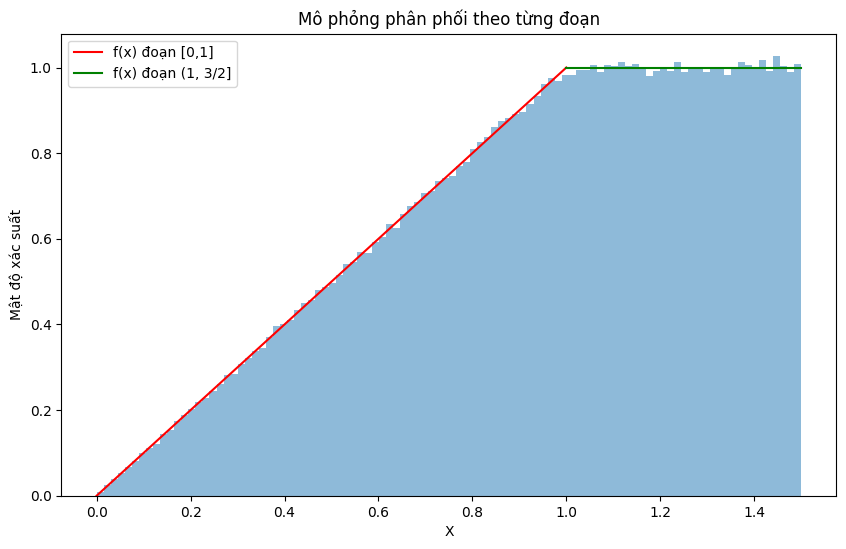

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(samples, bins=100, density=True, alpha=0.5)

x1 = np.linspace(0, 1, 100)
y1 = x1

x2 = np.linspace(1, 1.5, 100)
y2 = np.ones_like(x2)

plt.plot(x1, y1, 'r', label='f(x) đoạn [0,1]')
plt.plot(x2, y2, 'g', label='f(x) đoạn (1, 3/2]')

# Trang trí biểu đồ
plt.xlabel('X')
plt.ylabel('Mật độ xác suất')
plt.title('Mô phỏng phân phối theo từng đoạn')
plt.legend()
plt.show()

<br>

### **$d. \quad f(x) = \frac{1}{\pi(1 + x^2)}$**

#### **Lý thuyết**

$X$ là biến ngẫu liên tục trên $(-\infty, +\infty)$

Hàm phân phối tích lũy được biểu diễn dưới dạng:
$$
F(x) = P(X \le x) = \int_{-\infty}^{x}f(t)\,dt
$$

$\Rightarrow X$ có phân phối $F$: $\quad X \sim F$

$$
\begin{aligned}

\Rightarrow
F(x) &= \frac{1}{\pi} \cdot \int_{-\infty}^{x} \frac{1}{1 + t^2} \, dt \\ \\
     &= \frac{1}{\pi} \cdot (arctan(t)) \Big|_{-\infty}^{x}

\end{aligned}
$$

$\quad$ Khi $t \to -\infty$ thì $arctan(t) \to -\frac{\pi}{2}$

$$
\Rightarrow 
F(x) = \frac{1}{\pi} \cdot arctan(x) + \frac{1}{2}
$$

Nếu ta sinh ngẫu nhiên một số  $u \sim U(0, 1)$, bằng **phương pháp biến đổi ngược**, ta có thể sinh $X$ từ hàm phân phối $F(x)$, bằng cách giải phương trình $F(x) = u$:

$$
\begin{aligned}

F(x) &= \frac{1}{\pi} \cdot arctan(x) + \frac{1}{2} = u \\
     &\Rightarrow arctan(x) = (u - \frac{1}{2}) \cdot \pi \\ \\
     &\Rightarrow x = tan\left((u - \frac{1}{2}) \cdot \pi \right)

\end{aligned}
$$

$\Rightarrow$ Như vậy, với $u \sim U(0, 1)$ thì $X$ được sinh ra bằng cách:
$$
X = tan\left((u - \frac{1}{2}) \cdot \pi \right)
$$

Kì vọng của biến ngẫu nhiên $X$ được tính bởi:
$$
E[X] = \int_{-\infty}^{+\infty}xf(x)\,dx = \int_{-\infty}^{+\infty} \frac{x}{\pi(1 + x^2)} \, dx = \infty
$$

$\Rightarrow E[X]$ phân kì  
$\Rightarrow$ $E[X]$ không tồn tại.

#### **Code**

- Sinh số ngẫu nhiên $X$

In [24]:
def gen_X_2d():
    u = random.uniform(0, 1)
    
    return np.tan((u - 0.5) * np.pi)

In [25]:
gen_X_2d()

-2.3715700213038033

- Mô phỏng

In [26]:
def simulate_2d(simulations=100000):
    samples = []
    
    for _ in range(simulations):
        samples.append(gen_X_2d())
        
    return samples, np.mean(samples)

In [27]:
samples, estimated = simulate_2d(1000000)

print (f"-> Trung bình mẫu (Kỳ vọng phân kì): {estimated}")

-> Trung bình mẫu (Kỳ vọng phân kì): -1.0336241546287257


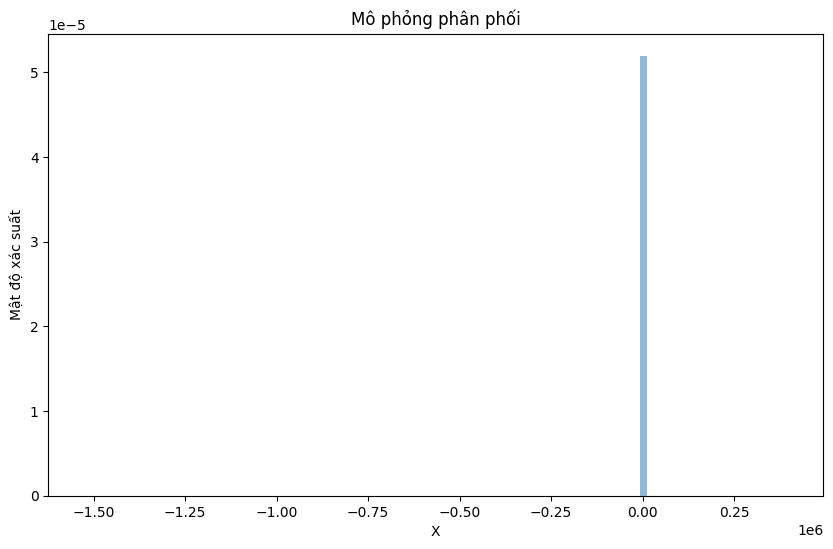

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(samples, bins=100, density=True, alpha=0.5)

x_values = np.linspace(-10, 10, 100)  
pdf_values = 1 / (np.pi * (1 + x_values**2))  

plt.title("Mô phỏng phân phối")
plt.xlabel("X")
plt.ylabel("Mật độ xác suất")

#plt.plot(x_values, pdf_values, color='red', label='Hàm mật độ xác suất')

plt.show()

---

## **Câu 3**

Dùng phương pháp Monte Carlo, đưa ra khoảng tin cậy 96% cho

$a.$
$$
I = \int_{-\infty}^{+\infty} e^{-x^2} |\sin x| dx
$$

$b.$

$$
I = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} e ^ {-\frac{1}{2}(x^2 + (y - 1)^2 - \frac{x(y - 1)}{4})} dx dy
$$

---

#### **$a. \quad I = \int_{-\infty}^{+\infty} e^{-x^2} |\sin x| dx$**

#### **Lý thuyết**

Theo [Wikipedia - Hàm Gauss](https://vi.wikipedia.org/wiki/H%C3%A0m_Gauss) có phân phối chuẩn, ta có:

$$
\begin{aligned}

\int_{-\infty}^{+\infty} e^{-x^2}dx = \sqrt{\pi} \\ \\

\Rightarrow
\int_{-\infty}^{+\infty} \frac{1}{\sqrt{\pi}} \cdot e^{-x^2}dx = 1

\end{aligned}
$$

$\Rightarrow$ Gọi $f(x) = \frac{1}{\sqrt{\pi}} \cdot e^{-x^2}$ là hàm mật độ xác suất của biến ngẫu nhiên $X \sim N(\mu, \sigma^2)$

-  Mà hàm mật độ của phân phối chuẩn tắc có dạng $g(y) = \frac{1}{\sqrt{2\pi}} e^{\frac{-y^2}{2}}$, $Y \sim N(0, 1)$
- Hay,  $g(y) = \frac{1}{\sqrt{2\pi}} e^{-t^2}$, Với $t = \frac{y}{\sqrt{2}}$

$\quad\quad \Rightarrow g(y) = \frac{1}{\sqrt{2}} f(t)$ hay $\sqrt{2} \cdot g(y) = f(t)$

$\quad\quad \Rightarrow X = \sqrt{2} \cdot Y$

$\quad\quad \Rightarrow X \sim N(0, \frac{1}{2})$

Ta có:

$I = \sqrt{\pi} \cdot \int_{-\infty}^{+\infty} |\sin x| \cdot f(x) \, dx$

$\Rightarrow I = \sqrt{\pi} \cdot E_f[|\sin X|]$

Giả sử ta sinh $N$ mẫu ngẫu nhiên độc lập $X_1, X_2, ..., X_N$ từ hàm phân phối của $f(x)$, ta có thể ước lượng trung bình mẫu $Y = |\sin{X}|$ bằng thống kê:
$$
\overline{Y_N} = \frac{1}{N} \cdot \sum_{i = 1}^{N} |\sin{X_i}|
$$

$\Rightarrow$ Ước lượng Monte Carlo của $I$ là: $\hat{I} = \sqrt{\pi} \cdot \overline{Y_N}$

Theo [định lý giới hạn trung tâm](https://vi.wikipedia.org/wiki/%C4%90%E1%BB%8Bnh_l%C3%BD_gi%E1%BB%9Bi_h%E1%BA%A1n_trung_t%C3%A2m), khi cỡ mẫu đủ lớn, thì $\overline{Y_N}$ sẽ có cùng giá trị kỳ vọng và phương sai:
- Giá trị kỳ vọng: $E[|\sin{X}|]$
- Phương sai: $\frac{\sigma^2}{N} \quad$ với $\sigma^2 = Var(|\sin{X}|)$

Cùng từ mẫu này, ta ước lượng $\sigma$ bằng thống kê:
$$
s = \sqrt{\frac{1}{N - 1} \cdot \sum_{i = 1}^{N}(|\sin{X_i}| - \overline{Y_N}\,)^2}
$$

Từ đó ta có ước lượng sai số chuẩn cho $\hat{I}$:
$$
\hat{\sigma}(\hat{I}) = \frac{ \sqrt{\pi} \cdot s}{\sqrt{N}}
$$

Với mức tin cậy $96\%$, thì với mức ý nghĩa $\alpha =  0.04$ và $z_{\frac{\alpha}{2}} = z_{0.02} \approx 2.05$, ta có khoảng tin cậy cho $I = \int_{-\infty}^{+\infty} e^{-x^2} |\sin x| dx$:

$$
[\hat{I} - z_{\frac{\alpha}{2}} \cdot \hat{\sigma}(\hat{I}) \quad,\quad \hat{I} + z_{\frac{\alpha}{2}} \cdot \hat{\sigma}(\hat{I})]
$$

Hay,

$$
[\sqrt{\pi} \cdot \overline{Y_N} - 2.05 \cdot \frac{ \sqrt{\pi} \cdot s}{\sqrt{N}} \quad,\quad \sqrt{\pi} \cdot \overline{Y_N} + 2.05 \cdot \frac{ \sqrt{\pi} \cdot s}{\sqrt{N}}]
$$

#### **Code**

- Mô phỏng

In [29]:
def simulate_3a(simulations=100000):
    sigma = math.sqrt(0.5)
    X = np.random.normal(loc=0.0, scale=sigma, size=simulations) # Draw random samples from a normal (Gaussian) distribution.
    Y = np.abs(np.sin(X))
    
    I_hat = np.mean(Y) * math.sqrt(math.pi)
    s_I = np.std(Y, ddof=1) *  math.sqrt(math.pi)
    ese_I = s_I / np.sqrt(simulations)
    
    return I_hat, s_I, ese_I

def cal_confidence_interval(I_hat, ese_I, confidence=0.96):
    z = st.norm.ppf(1 - confidence/2) 
    
    CI_lower = I_hat - z * ese_I
    CI_upper = I_hat + z * ese_I
    
    return CI_lower, CI_upper

In [30]:
N = 100000

I_hat, s_I, ese_I = simulate_3a(N)
CI_lower, CI_upper = cal_confidence_interval(I_hat, ese_I)

print(f"- Số lượng mẫu: {N}")
print(f"- Uớc lượng I: {I_hat.round(4)}")
print(f"- Độ lệch chuẩn mẫu: {s_I.round(4)}")
print(f"- Sai số chuẩn: {ese_I.round(4)}")
print(f"- Khoảng tin cậy 96%: [{CI_lower.round(4)}, {CI_upper.round(4)}]")

- Số lượng mẫu: 100000
- Uớc lượng I: 0.8508
- Độ lệch chuẩn mẫu: 0.5228
- Sai số chuẩn: 0.0017
- Khoảng tin cậy 96%: [0.8507, 0.8509]


<br>

### **$b. \quad I = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} e ^ {-\frac{1}{2}(x^2 + (y - 1)^2 - \frac{x(y - 1)}{4})} \,dx \,dy$**

Gọi $f(x, y) = e^{ -\frac{1}{2} \left( x^2 + (y - 1)^2 - \frac{x (y - 1)}{4} \right) }$   

$\Rightarrow I =  \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \,dx \,dy$

Giả sử ta sinh $N$ cặp mẫu ngẫu nhiên độc lập $(X_i, Y_i)$ từ phân phối đề xuất $p$. Khi đó:
$$
I \approx \frac{1}{N}\sum_{i=1}^N \frac{f(X_i, Y_i)}{p(X_i, Y_i)} \approx \frac{1}{N}\sum_{i=1}^N \frac{f(X_i, Y_i)}{p(X_i)p(Y_i)}
$$


$\quad\quad$ Do $X$ và $Y$ độc lập nên:
$$
p(X, Y) = p(X) \cdot p(Y)
$$


Với:
- $f(x, y)$ là hàm mục tiêu dưới dấu tích phân.
- $p$ là mật độ phân phối để sinh mẫu

Do miền là $\mathbb{R}^2$, ta chọn:

$$
p(x) = N(0, 5)
$$

$$
p(y) = N(0, 5)
$$

Tức là sinh mẫu từ phân phối chuẩn rộng $N(0, 5)$ để có thể bao phủ được cả miền $(-\infty, +\infty)$.


Với mỗi cặp $(X_i, Y_i)$ sinh ra từ $N(0, 5)$, ta tính trọng số:

$$
w_i = \frac{f(X_i, Y_i)}{p(X_i)p(Y_i)}
$$

Với:

$$
p(x) = \frac{1}{\sqrt{2\pi \cdot 5^2}} \cdot e^{ -\frac{x^2}{2 \cdot 5^2} } \quad \text{(PDF của phân phối chuẩn đối với biến 1 chiều)}
$$


$\Rightarrow$ Ước lượng Monte Carlo của $I$:

$$
\hat{I} = \frac{1}{N} \sum_{i=1}^{N} w_i = \bar{w}
$$


Cùng từ mẫu này, ta ước lượng $\sigma$ bằng thống kê:

$$
s = \sqrt{\frac{1}{N - 1}\sum_{i=1}^{N} (w_i - \bar{w})^2}
$$

Từ đó ta có ước lượng sai số chuẩn cho $\hat{I}$:

$$
\hat{\sigma}(\hat{I}) = \frac{s}{\sqrt{N}}
$$


Với mức tin cậy $96\%$, thì với mức ý nghĩa $\alpha =  0.04$ và $z_{\frac{\alpha}{2}} = z_{0.02} \approx 2.05$, ta có khoảng tin cậy cho $I = \int_{-\infty}^{\infty} \int_{-\infty}^{\infty} e ^ {-\frac{1}{2}(x^2 + (y - 1)^2 - \frac{x(y - 1)}{4})} \,dx \,dy$:

$$
[\hat{I} - z_{\frac{\alpha}{2}} \cdot \hat{\sigma}(\hat{I}) \quad,\quad \hat{I} + z_{\frac{\alpha}{2}} \cdot \hat{\sigma}(\hat{I})]
$$

Hay,

$$
[\bar{w} - 2.05 \cdot \frac{s}{\sqrt{N}} \quad,\quad \bar{w} + 2.05 \cdot \frac{s}{\sqrt{N}}]
$$

#### **Code**

- Mô phỏng

In [31]:
import numpy as np
import math
import scipy.stats as st

def target_density(x, y):
    return np.exp(-0.5 * (x**2 + (y-1)**2 - (x*(y-1))/4))

def proposal_density(x):
    sigma = 5
    return (1 / (math.sqrt(2 * math.pi) * sigma)) * np.exp(-0.5 * (x / sigma)**2)

def simulate_3b(simulations=100000):
    sigma = 5
    X = np.random.normal(loc=0.0, scale=sigma, size=simulations)
    Y = np.random.normal(loc=0.0, scale=sigma, size=simulations)

    f_values = target_density(X, Y)
    p_x = proposal_density(X)
    p_y = proposal_density(Y)

    weights = f_values / (p_x * p_y)

    I_hat = np.mean(weights)
    s_I = np.std(weights, ddof=1)
    ese_I = s_I / np.sqrt(simulations)

    return I_hat, s_I, ese_I

def cal_confidence_interval(I_hat, ese_I, confidence=0.96):
    z = st.norm.ppf(1 - confidence/2) 
    
    CI_lower = I_hat - z * ese_I
    CI_upper = I_hat + z * ese_I

    return CI_lower, CI_upper

In [32]:
N = 100000

I_hat, s_I, ese_I = simulate_3b(N)

CI_lower, CI_upper = cal_confidence_interval(I_hat, ese_I)

print(f"- Số lượng mẫu: {N}")
print(f"- Ước lượng I: {I_hat:.4f}")
print(f"- Độ lệch chuẩn mẫu: {s_I:.4f}")
print(f"- Sai số chuẩn: {ese_I:.4f}")
print(f"- Khoảng tin cậy 96%: [{CI_lower:.4f}, {CI_upper:.4f}]")

- Số lượng mẫu: 100000
- Ước lượng I: 6.3079
- Độ lệch chuẩn mẫu: 21.7225
- Sai số chuẩn: 0.0687
- Khoảng tin cậy 96%: [6.3045, 6.3114]


---

## **Câu 4**

Cho $X \sim N(0, 1)$, dùng phương pháp Monte Carlo, ước lượng các giá trị sau với sai số không quá $0.001$.  

$a. \; P(0 < X < 1)$  

$b. \; P(10 < X < 11)$  

$c. \; P(X < 10.5 \;|\; 10 < X < 11)$  

$d. \; E(X | 10 < X < 11)$  


---

### **$a. \; P(0 < X < 1)$**

#### **Lý thuyết**

Theo đề, $X \sim N(0, 1)$, với $\mu = 0$ và $\sigma^2 = 1$, từ đó ta có hàm phân phối tích lũy:

$$
\phi(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi}} e^{-\frac{t^2}{2}} \, dt 
$$

$$
\Rightarrow
\begin{cases}

\phi(1) \approx 0.8413\\

\phi(0) \approx 0.5

\end{cases}
$$

$\Rightarrow$ Xác suất thực tế (bằng cách tra bảng phân phối chuẩn):
$$
\hat{p} = P(0 < X < 1) = P(X < 1) - p(X < 0) = \phi(1) - \phi(0) \approx 0.3413
$$

Giả sử ta sinh $N$ mẫu ngẫu nhiên độc lập $X_1, X2, ..., X_N$ từ hàm phân phối. Để tính $P(0 < X < 1)$, ta phải đếm có bao nhiêu mẫu thõa điều kiện $0 < X < 1$

Mỗi lần, xét X_i có thõa mãn điều kiện $0 < X < 1$ hay không như một phép thử $Bernoulli$:
- Thõa $\to 1$
- Ngược lại $\to 0$

$\Rightarrow \hat{p}$ chính là trung bình của $N$ phép thử $Bernoulli$

$\Rightarrow Var(f(X)) = \hat{p}(1 - \hat{p})$

Ước lượng Monte Carlo cho $E[f(x)]$ được định nghĩa là:

$$
Z_{N}^{MC} = \frac{1}{N} \sum_{i = 1}^{N}f(X_i)
$$

Với: 
$$
f(x) =
\begin{cases}
1 & \text{nếu } 0 < x < 1 \\
0 & \text{khác}
\end{cases}
$$


Ước lượng Monte Carlo cho $E[f(x)]$ có sai số chuẩn:
$$
\sigma = \sqrt{\frac{Var(f(X))}{N}} = \sqrt{\frac{\hat{p}(1 - \hat{p})}{N}}
$$

Để số mẫu $N$ tối thiểu cần thiết để sai số không quá $0.001$:

$$
\begin{aligned}

&\sigma \le 0.001 \\ \\

&\Rightarrow \sqrt{\frac{\hat{p}(1 - \hat{p})}{N}} \le 0.001 \\ \\

&\Rightarrow N \ge \frac{\hat{p}(1 - \hat{p})}{0.001^2} \\ \\

&\Rightarrow N \ge 224814.31

\end{aligned}
$$

$\Rightarrow$ Ta cần ít nhất khoảng **224,815 mẫu** để sai số không quá $0.001$

#### **Code**

- Mô phỏng

In [33]:
def cal_se_4a(simulations=224815):
    samples = np.random.normal(0, 1, simulations)
    
    count_satisfaction = np.sum((samples > 0) & (samples < 1))
    
    p_hat = count_satisfaction / simulations
    
    se = np.sqrt(p_hat * (1 - p_hat) / simulations)
    
    return se, p_hat

def MC_estimator_a(N):
    X = np.random.normal(0, 1, size=N)
    return np.mean((X > 0) & (X < 1))

In [34]:
N = 224815
se, p_hat = cal_se_4a(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat.round(4)}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 224815
Ước lượng Monte Carlo P(0 < X < 1): 0.3414
Sai số chuẩn: 0.001


In [35]:
N = 1000
se, p_hat = cal_se_4a(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat.round(4)}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 1000
Ước lượng Monte Carlo P(0 < X < 1): 0.322
Sai số chuẩn: 0.01478


In [36]:
MC_est_a_1 = np.fromiter((MC_estimator_a(1000) for _ in range(5000)), dtype=float)
MC_est_a_2 = np.fromiter((MC_estimator_a(224815) for _ in range(5000)), dtype=float)

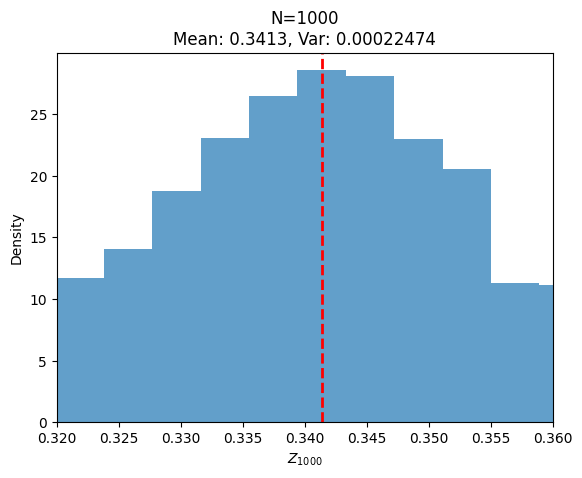

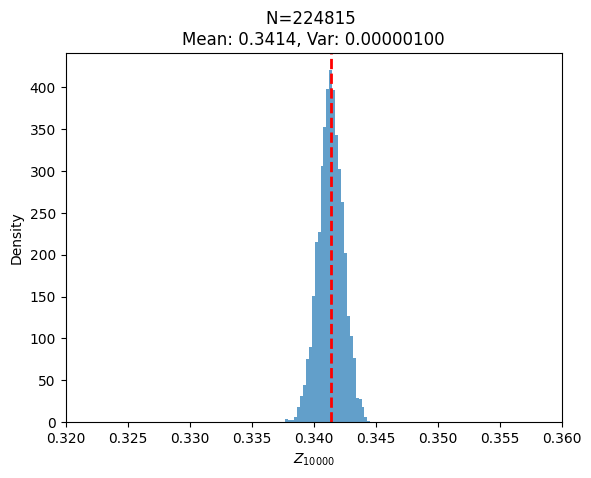

In [37]:
#N=1000
plt.hist(MC_est_a_1, density=True, bins=30, alpha=0.7)
plt.axvline(x=np.mean(MC_est_a_1), color="red", linestyle='dashed', linewidth=2)
plt.xlim(0.32, 0.36)
plt.title("N=1000\nMean: {0:.4f}, Var: {1:.8f}".format(np.mean(MC_est_a_1), np.var(MC_est_a_1, ddof=1)))
plt.xlabel("$Z_{1000}$")
plt.ylabel("Density")
plt.show()

#N=224815
plt.hist(MC_est_a_2, density=True, bins=30, alpha=0.7)
plt.axvline(x=np.mean(MC_est_a_2), color="red", linestyle='dashed', linewidth=2)
plt.xlim(0.32, 0.36)
plt.title("N=224815 \nMean: {0:.4f}, Var: {1:.8f}".format(np.mean(MC_est_a_2), np.var(MC_est_a_2, ddof=1)))
plt.xlabel("$Z_{10000}$")
plt.ylabel("Density")
plt.show()


<br>

### **$b. \; P(10 < X < 11)$**

#### **Lý thuyết**

Làm tương tự câu $(a)$, ta tính được xác suất như sau:
$$
\hat{p} = \phi(11) - \phi(10) \approx 0
$$

$\rightarrow$ Xác suất này rất nhỏ và gần như bằng $0$

In [38]:
p_hat = p = norm.cdf(11) - norm.cdf(10)

print(f"Xác suất thực P(10 < X < 11) = {p_hat:.30f}")

Xác suất thực P(10 < X < 11) = 0.000000000000000000000000000000


Để số mẫu $N$ tối thiểu cần thiết để sai số không quá $0.001$:

$$
\begin{aligned}

&\sigma \le 0.001 \\ \\

&\Rightarrow \sqrt{\frac{\hat{p}(1 - \hat{p})}{N}} \le 0.001 \\ \\

&\Rightarrow N \ge \frac{\hat{p}(1 - \hat{p})}{0.001^2} \\ \\

&\Rightarrow N \ge 0

\end{aligned}
$$

#### **Code**

- Mô phỏng

In [39]:
def cal_se_4b(simulations=100000):
    samples = np.random.normal(0, 1, simulations)
    
    count_satisfaction = np.sum((samples > 10) & (samples < 11))
    
    p_hat = count_satisfaction / simulations
    
    se = np.sqrt(p_hat * (1 - p_hat) / simulations)
    
    return se, p_hat

In [40]:
N = 1
se, p_hat = cal_se_4b(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat.round(4)}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 1
Ước lượng Monte Carlo P(0 < X < 1): 0.0
Sai số chuẩn: 0.0


In [41]:
N = 100000
se, p_hat = cal_se_4b(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat.round(4)}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 100000
Ước lượng Monte Carlo P(0 < X < 1): 0.0
Sai số chuẩn: 0.0


<br>

### **$c. \; P(X < 10.5 \;|\; 10 < X < 11)$**

#### **Lý thuyết**

Xác suất có điều kiện có công thức:
$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

$$
\Rightarrow
P(X < 10.5 \mid 10 < X < 11) = \frac{P(10 < X < 10.5)}{P(10 < X < 11)}
$$


$\to$ Từ câu $(b)$, ta biết $P(10 < X < 11)$ có xác suất rất nhỏ gần như bằng 0 nên viết tính $P(X < 10.5 \mid 10 < X < 11)$ hầu như không thể tính được.

$\to$ Ta không thể tính được $N$ mẫu chính xác .

In [42]:
cdf_10 = norm.cdf(10)
cdf_10_5 = norm.cdf(10.5)
cdf_11 = norm.cdf(11)

denominator = cdf_11 - cdf_10

if denominator == 0:
    print("Mẫu số bằng 0, không thể tính xác suất có điều kiện.")
else:
    conditional_prob = (cdf_10_5 - cdf_10) / denominator
    print(f"P(X < 10.5 | 10 < X < 11) = {conditional_prob:.10f}")


Mẫu số bằng 0, không thể tính xác suất có điều kiện.


#### **Code**

- Mô phỏng

In [43]:
def cal_se_4c(simulations=100000):
    samples = np.random.normal(0, 1, simulations)
    
    condition_1 = (samples > 10) & (samples < 11)
    condition_2 = (samples > 10) & (samples < 10.5)

    count_satisfaction = np.sum(condition_1) / np.sum(condition_2) if np.sum(condition_2) > 0 else 0
    
    p_hat = count_satisfaction / simulations
    
    se = np.sqrt(p_hat * (1 - p_hat) / simulations)
    
    return se, p_hat


In [44]:
N = 100000
se, p_hat = cal_se_4c(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 100000
Ước lượng Monte Carlo P(0 < X < 1): 0.0
Sai số chuẩn: 0.0


### **$d. \; E(X | 10 < X < 11)$**

#### **Lý thuyết**

Ước lượng Monte Carlo cho $E[f(x)]$ được định nghĩa là:

$$
Z_{N}^{MC} = \frac{1}{N} \sum_{i = 1}^{N}X_i \quad \text{Với } X_i \in (10, 11)
$$

#### **Code**

- Mô phỏng

In [45]:
def cal_se_4d(simulations=100000):
    samples = np.random.normal(0, 1, simulations)
    
    count_satisfaction = np.sum((samples > 10) & (samples < 11))
    
    p_hat = count_satisfaction / simulations
    
    se = np.sqrt(p_hat * (1 - p_hat) / simulations)
    
    return se, p_hat

In [46]:
N = 100000
se, p_hat = cal_se_4d(N)

print(f"Số lượng mẫu: {N}")
print(f"Ước lượng Monte Carlo P(0 < X < 1): {p_hat.round(4)}")
print(f"Sai số chuẩn: {se.round(5)}")


Số lượng mẫu: 100000
Ước lượng Monte Carlo P(0 < X < 1): 0.0
Sai số chuẩn: 0.0


---
## **Nguồn Tham Khảo**

**1. Slide của thầy Vũ Quốc Hoàng - Bài 2: Ôn tập biến ngẫu nhiên**  
**2. Slide của thầy Vũ Quốc Hoàng - Bài 3: Phương pháp Monte Carlo và sinh số ngẫu nhiên**  
**3. [Create A List of Random Number Without Duplicates](https://stackoverflow.com/questions/9755538/how-do-i-create-a-list-of-random-numbers-without-duplicates)**  
**4. [Hàm mật độ xác suất của biến liên tục](https://dominhhai.github.io/vi/2017/10/prob-rand-var/#2-2-h%C3%A0m-m%E1%BA%ADt-%C4%91%E1%BB%99-x%C3%A1c-su%E1%BA%A5t-c%E1%BB%A7a-bi%E1%BA%BFn-li%C3%AAn-t%E1%BB%A5c)**  
**5. [Calculus - Mathway](https://www.mathway.com/vi/Calculus)**  
**6. [Wikipedia - Phân phối mũ](https://vi.wikipedia.org/wiki/Ph%C3%A2n_ph%E1%BB%91i_m%C5%A9)**  
**7. [Wikipedia - Hàm Gauss](https://vi.wikipedia.org/wiki/H%C3%A0m_Gauss)**  
**8. [Wikipedia - Phân phối chuẩn](https://vi.wikipedia.org/wiki/Ph%C3%A2n_ph%E1%BB%91i_chu%E1%BA%A9n#:~:text=Ph%C3%A2n%20ph%E1%BB%91i%20chu%E1%BA%A9n%20(Ti%E1%BA%BFng%20Anh,(ph%C6%B0%C6%A1ng%20sai%20%CF%832).))**  
**9. [Estimation](https://www.fmu.ac.jp/home/public_h/ebm/report/images/10%2095%20percent%20CI%20and%20P_VN.pdf)**  
**10. [Định lý giới hạn trung tâm](https://vi.wikipedia.org/wiki/%C4%90%E1%BB%8Bnh_l%C3%BD_gi%E1%BB%9Bi_h%E1%BA%A1n_trung_t%C3%A2m)**  
**11. [[Xác Suất] Một số phân phối phổ biến](https://dominhhai.github.io/vi/2017/10/prob-com-var/#2-2-ph%C3%A2n-ph%E1%BB%91i-chu%E1%BA%A9n-normal-distribution)**  
**12. [Wikipedia - Phân phối chuẩn nhiều chiều](https://vi.wikipedia.org/wiki/Ph%C3%A2n_ph%E1%BB%91i_chu%E1%BA%A9n_nhi%E1%BB%81u_chi%E1%BB%81u)**   
**13. [Wikipedia - Hàm lỗi](https://vi.wikipedia.org/wiki/H%C3%A0m_l%E1%BB%97i)**  
**14. [Bảng tra phân phối chuẩn](https://www.slideshare.net/slideshow/bang-tra-phn-phi-chun/45410318)**  

$$***$$